In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [17]:
# create our state schema
class AgentState(TypedDict):
  length: int
  width: int
  area:int
  perimeter:int

In [18]:
# Our area node--> Defined as a function that performs one function
def get_area(state: AgentState)-> AgentState:
  """Calculates the Area using length and width"""
  state['area']=state['length']*state['width']

  return state


def get_perimeter(state: AgentState)-> AgentState:
  """Calculate Perimeter from length and width"""
  state['perimeter']= 2*(state['length'] + state['width'])

  return state

In [19]:
# create the graph
graph=StateGraph(AgentState)

# add our nodes(functions)
graph.add_node("area", get_area)
graph.add_node("perimeter", get_perimeter)

# Now add edges--> connecting nodes and tells the graph what to execute
graph.set_entry_point("area")
graph.add_edge("area", "perimeter")
graph.set_finish_point("perimeter")

# compile the graph to an executable
app=graph.compile()


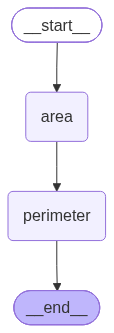

In [20]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
# pass in values and see if it executed our nodes and displays the correct results
app.invoke({"length":20, "width":6})

{'length': 20, 'width': 6, 'area': 120, 'perimeter': 52}